In [7]:
import pandas as pd
import numpy as np
import scanpy as sc
from scipy import sparse
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from arboreto.algo import grnboost2
from dask.diagnostics import ProgressBar

In [17]:
"""
Base GRN inference (GRNBoost2 only):
- Select HVGs
- Run GRNBoost2 once
- Return edges with importance scores

Output:
  df_G : DataFrame ['tf','target','importance']

Author: [Your Name]
"""

import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from arboreto.algo import grnboost2
from dask.diagnostics import ProgressBar


# --------------------------- #
# Utilities
# --------------------------- #

def strip_ver(x):
    """Remove Ensembl version suffix (e.g., ENSG000001234.7 → ENSG000001234)."""
    s = str(x)
    return s.split('.')[0] if '.' in s else s


def _standardize_grnboost_columns(df):
    """Normalize GRNBoost2 columns to ['tf', 'target', 'importance']."""
    cols_lower = {c.lower(): c for c in df.columns}
    if 'regulator' in cols_lower:
        tf_col = cols_lower['regulator']
    elif 'tf' in cols_lower:
        tf_col = cols_lower['tf']
    else:
        raise ValueError(f"TF column not found in: {list(df.columns)}")

    if 'target' in cols_lower:
        target_col = cols_lower['target']
    else:
        raise ValueError(f"Target column not found in: {list(df.columns)}")

    if 'importance' in cols_lower:
        imp_col = cols_lower['importance']
    elif 'score' in cols_lower:
        imp_col = cols_lower['score']
    else:
        raise ValueError(f"Importance/Score column not found in: {list(df.columns)}")

    return df.rename(columns={tf_col: 'tf', target_col: 'target', imp_col: 'importance'})[['tf', 'target', 'importance']]


# --------------------------- #
# Main: single-run GRNBoost2
# --------------------------- #

def _get_tf_symbols_from_csv(tf_csv):
    """Load TF symbols from human_tfs.csv (same as SCENIC+ pipeline)."""
    df = pd.read_csv(tf_csv)
    col = [c for c in df.columns if "symbol" in c.lower()]
    if not col:
        return set()
    return set(df[col[0]].dropna().astype(str).str.strip().str.upper().unique())


def run_grnboost2_base(
    rna,
    tf_csv,
    n_top_genes=None,
    prefiltered=False
):
    """
    Run GRN inference using a single GRNBoost2 pass.

    If prefiltered=True: use rna as-is (same dataset as SCENIC+ input, no extra filtering).
    If prefiltered=False: apply HVG+TF selection (seurat, n_top=15000, batch_key=donor_id).

    Steps:
      1) Optionally select HVGs + TF whitelist, or use rna as-is when prefiltered=True
      2) Build dense expression matrix (deduplicate Ensembl IDs by mean if needed)
      3) Intersect TF list with expressed genes
      4) Run GRNBoost2 once and return edges with importance

    Returns:
        df_G : DataFrame with ['tf','target','importance']
    """
    tf_symbols = _get_tf_symbols_from_csv(tf_csv)
    if prefiltered:
        # Same dataset as SCENIC+ (already HVG+TF or as prepared); no extra filtering
        print("[1] Using prefiltered dataset as-is (same as SCENIC+ input, no extra filtering).")
        rna_hvg = rna.copy()
    else:
        # ---- 1. HVGs (same as SCENIC+ pipeline: hvg_plus_tf) ----
        print("[1] Selecting highly variable genes (SCENIC+ strategy: seurat, n_top=15000, batch_key=donor_id, + TF whitelist)...")
        n_top = min(15000, rna.n_vars - 1) if n_top_genes is None else min(int(n_top_genes), rna.n_vars - 1)
        batch_key = "donor_id" if "donor_id" in rna.obs.columns else None
        sc.pp.highly_variable_genes(rna, n_top_genes=n_top, batch_key=batch_key, flavor="seurat")
        hv = rna.var["highly_variable"].to_numpy()
        for i, g in enumerate(rna.var_names):
            if str(g).upper() in tf_symbols:
                hv[i] = True
        rna.var["highly_variable"] = hv
        rna_hvg = rna[:, rna.var["highly_variable"]].copy()

    # ---- 2. Dense matrix ----
    print("[2] Converting to dense matrix...")
    if sparse.issparse(rna_hvg.X):
        X = pd.DataFrame(rna_hvg.X.toarray(), index=rna_hvg.obs_names, columns=rna_hvg.var_names)
    else:
        X = pd.DataFrame(rna_hvg.X, index=rna_hvg.obs_names, columns=rna_hvg.var_names)

    # Strip Ensembl versions and collapse duplicates
    X.columns = [strip_ver(g) for g in X.columns]
    if len(set(X.columns)) < len(X.columns):
        X = X.T.groupby(level=0).mean().T
        print(f"[info] Collapsed duplicated Ensembl IDs; now {X.shape[1]} genes.")

    # ---- 3. TF intersection (support both Ensembl and symbol var_names, e.g. SCENIC+ input) ----
    print("[3] Loading TF list...")
    gene_names_set = set(X.columns)
    tf_cols = sorted(g for g in X.columns if str(g).upper() in tf_symbols)
    if len(tf_cols) == 0:
        tfs = pd.read_csv(tf_csv)
        tfs = tfs[tfs["Is TF?"] == "Yes"]
        ens_col = [c for c in tfs.columns if "ensembl" in c.lower()][0]
        tfs["ens_base"] = tfs[ens_col].astype(str).apply(strip_ver)
        tf_cols = sorted(set(tfs["ens_base"]).intersection(gene_names_set))
    if len(tf_cols) == 0:
        raise ValueError("No TFs from the provided list are present in the dataset after preprocessing.")
    print(f"[info] Found {len(tf_cols)} TFs present in dataset.")

    # ---- 4. GRNBoost2 ----
    print("[4] Running GRNBoost2...")
    with ProgressBar():
        net = grnboost2(X.astype(np.float32), gene_names=list(X.columns), tf_names=list(tf_cols))

    df_G = _standardize_grnboost_columns(net).sort_values('importance', ascending=False).reset_index(drop=True)
    print(f"[Done] ✅ {len(df_G)} edges inferred.")
    return df_G


# --------------------------- #
# Example usage
# --------------------------- #

# rna = sc.read_h5ad("/path/to/rna_subset.h5ad")
# tf_csv = "/path/to/human_tfs.csv"
# df_G = run_grnboost2_base(rna, tf_csv, n_top_genes=3000)
# print(df_G.head())


In [15]:
rna_path = "../../code/05_scenicplus/data_inputs/SEAAD_MTG_microglia_rna.h5ad"
tf_csv   = "../../data/human_tfs.csv"


rna = sc.read(rna_path)

# Same GEX as SCENIC+ (config GEX_anndata_fname); no extra HVG/filtering in baseline

# Run GRNBoost2 on same dataset as SCENIC+



/opt/anaconda3/envs/scenic/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [20]:
grnboost = run_grnboost2_base(rna, tf_csv, prefiltered=True)
# Re-run the cell that defines run_grnboost2_base if you get 'unexpected keyword argument prefiltered'

[1] Using prefiltered dataset as-is (same as SCENIC+ input, no extra filtering).
[2] Converting to dense matrix...
[3] Loading TF list...
[info] Found 2703 TFs present in dataset.
[4] Running GRNBoost2...


/opt/anaconda3/envs/scenic/lib/python3.11/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 192.37 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
2026-02-26 20:44:07,465 - tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of <SystemMonitor: cpu: 72 memory: 198 MB fds: 47>>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/scenic/lib/python3.11/site-packages/tornado/ioloop.py", line 945, in _run
    val = self.callback()
          ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/scenic/lib/python3.11/site-packages/distributed/system_monitor.py", line 168, in update
    net_ioc = psutil.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/scenic/lib/python3.11/site-packages/psutil/__init__.py", line 2148, in net_io_counters
    rawdict = _psplatform.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
OSError

KeyboardInterrupt: 

In [147]:
import pandas as pd
import re

def load_gtf_mapping(gtf_path):
    """
    Parse a 10x reference GTF file to get Ensembl → gene symbol mapping.

    Returns a dict: {ensembl_id: gene_symbol}
    """
    ens_to_sym = {}
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            fields = line.strip().split('\t')
            if fields[2] != 'gene':
                continue
            attr_field = fields[-1]
            # Extract attributes like gene_id "ENSG..."; gene_name "TP53";
            gene_id = re.search(r'gene_id "([^"]+)"', attr_field)
            gene_name = re.search(r'gene_name "([^"]+)"', attr_field)
            if gene_id and gene_name:
                ens = gene_id.group(1).split('.')[0]  # remove version suffix
                sym = gene_name.group(1)
                ens_to_sym[ens] = sym
    print(f"[info] Loaded {len(ens_to_sym):,} gene mappings from GTF.")
    return ens_to_sym


In [148]:
# Load mapping once
mapping = load_gtf_mapping("../../data/refdata-gex-GRCh38-2020-A/genes/genes.gtf")

# ---- Apply mapping and print mapping stats ----
def add_symbol_columns(df, mapping, id_cols=('tf', 'target'), show_examples=5):
    """
    Add gene symbol columns and print how many Ensembl IDs couldn't be mapped.
    """
    df = df.copy()
    for col in id_cols:
        # Map Ensembl → symbol (strip version suffix if needed)
        df[f"{col}_symbol"] = df[col].map(lambda x: mapping.get(str(x).split('.')[0]) if pd.notnull(x) else None)

        # Identify unmapped
        missing_mask = df[f"{col}_symbol"].isna()
        num_missing = missing_mask.sum()
        total = len(df)
        unique_missing = sorted(set(str(x).split('.')[0] for x in df.loc[missing_mask, col] if pd.notnull(x)))

        # Print results
        print(f"[{col}] mapped {total - num_missing:,}/{total:,} rows "
              f"({(total - num_missing) / total * 100:.2f}% mapped)")
        if unique_missing:
            print(f"   Unmapped unique IDs: {len(unique_missing)}")
            print(f"   Examples: {', '.join(unique_missing[:show_examples])}")
        else:
            print("   ✅ All IDs mapped successfully")

    return df

[info] Loaded 36,601 gene mappings from GTF.


In [ ]:
def create_cutoff(df, score_col="importance", frac = 0.02):
    
    """Create a cutoff DataFrame retaining only the top fraction of edges by score."""

    threshold = df[score_col].quantile(1 - frac)    
    df = df[df[score_col] >= threshold]
    return df

In [149]:
GRNboost = add_symbol_columns(grnboost, mapping)

[tf] mapped 2,155,399/2,156,357 rows (99.96% mapped)
   Unmapped unique IDs: 1
   Examples: ENSG00000228623
[target] mapped 2,155,609/2,156,357 rows (99.97% mapped)
   Unmapped unique IDs: 10
   Examples: ENSG00000223628, ENSG00000228623, ENSG00000288631, ENSG00000288649, ENSG00000288675
[tf] mapped 2,011,969/2,012,760 rows (99.96% mapped)
   Unmapped unique IDs: 1
   Examples: ENSG00000228623
[target] mapped 2,011,903/2,012,760 rows (99.96% mapped)
   Unmapped unique IDs: 10
   Examples: ENSG00000228623, ENSG00000288631, ENSG00000288642, ENSG00000288649, ENSG00000288675


In [150]:
networks = {"GRNboost": GRNboost}

for name, df in networks.items():
    df = create_cutoff(df, frac = 0.5)
    networks[name] = df

for name, df in networks.items():
    out_path = f"./grn_df/{name}_top{n_top_genes}_edges.csv"
    df.to_csv(out_path, index=False)
    print(f"[saved] {name} to {out_path}")

[saved] diseased_GRNboost to ./grn_df/diseased_GRNboost_top36412_edges.csv
[saved] healthy_GRNboost to ./grn_df/healthy_GRNboost_top36412_edges.csv


In [ ]:
GRNboost = pd.read_csv("./grn_df/GRNboost_top{n_top_genes}_edges.csv".format(n_top_genes=n_top_genes))

networks = {"GRNboost": GRNboost}


In [152]:
nx_networks = {}

for name, df in networks.items():
    
    graph = nx.from_pandas_edgelist(df, source='tf', target='target', edge_attr='importance', create_using=nx.DiGraph)
    nx_networks[name] = graph

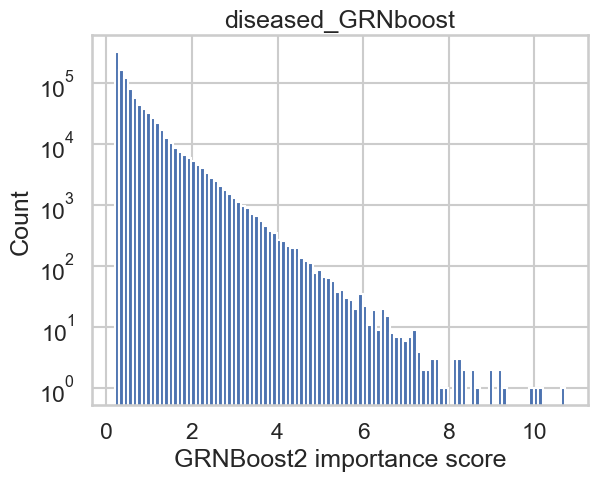

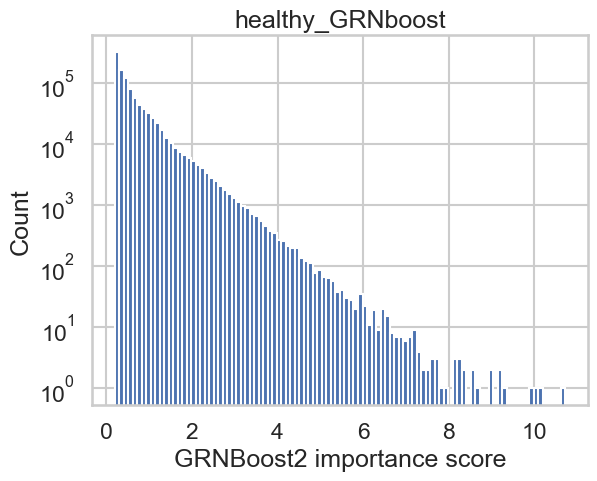

In [153]:
for name, graph in nx_networks.items():
    
    plt.figure()
    df['importance'].plot.hist(bins=100, log=True)
    plt.xlabel("GRNBoost2 importance score")
    plt.ylabel("Count")
    plt.title(name)
    plt.show()

In [154]:
import pandas as pd
import networkx as nx

def compute_hubs_degree_centrality(df, tf_col="tf_symbol", target_col="target"):
    """
    Compute TF hub metrics using ONLY out-degree centrality.
    Expects columns: tf_col (regulator), target_col (target). Ignores weights.
    Returns: DataFrame indexed by TF with ['degree','degree_centrality','hub_score'].
    """
    if df.empty:
        return pd.DataFrame(columns=["degree", "degree_centrality", "hub_score"])

    # Build directed graph (unweighted for pure degree centrality)
    G = nx.from_pandas_edgelist(
        df, source=tf_col, target=target_col, create_using=nx.DiGraph()
    )

    N = G.number_of_nodes()
    if N <= 1:
        tf_nodes = pd.Index(df[tf_col].unique())
        zeros = pd.Series(0.0, index=tf_nodes)
        out_deg = pd.Series(0, index=tf_nodes, dtype=int)
        hubs = pd.DataFrame({
            "degree": out_deg,
            "degree_centrality": zeros,
            "hub_score": zeros,   # hub_score == degree_centrality (per your request)
        })
        return hubs

    # Unweighted out-degree and out-degree centrality
    out_deg_dict = dict(G.out_degree(weight=None))
    tf_nodes = pd.Index(df[tf_col].unique())
    # keep only TF nodes
    out_deg = pd.Series({n: out_deg_dict.get(n, 0) for n in tf_nodes}, dtype=float)

    out_deg_cent = out_deg / (N - 1)  # classic degree centrality normalization

    hubs = pd.DataFrame({
        "degree": out_deg.astype(int),
        "degree_centrality": out_deg_cent
    })
    # Hub score == degree centrality only
    hubs["hub_score"] = hubs["degree_centrality"]

    return hubs.sort_values("hub_score", ascending=False)

# ==== Run for both conditions ====
h = compute_hubs_degree_centrality(GRNboost)

# merged kept for downstream (single network: delta=0)
merged = h.copy()
merged["hub_score_H"] = merged["hub_score"]
merged["hub_score_D"] = merged["hub_score"]
merged["delta"] = 0
merged = merged.sort_values("hub_score", ascending=False)


In [159]:
h

,degree,degree_centrality,hub_score
MEF2A,3976,0.145625,0.145625
MEF2C,3358,0.122990,0.122990
TCF12,3103,0.113651,0.113651
FOXN3,3052,0.111783,0.111783
ZBTB20,2971,0.108816,0.108816
...,...,...,...
SPIC,41,0.001502,0.001502
GATA6,40,0.001465,0.001465
ETV3L,37,0.001355,0.001355
EN2,36,0.001319,0.001319


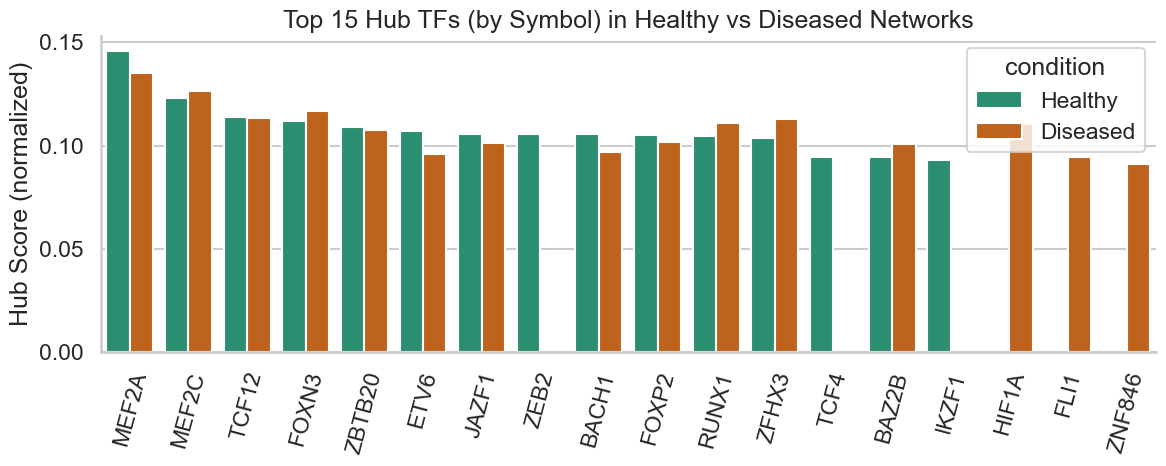

In [160]:
sns.set_theme(style="whitegrid", context="talk")

topN = 15
plot_df = h.head(topN).reset_index(names='TF')

plt.figure(figsize=(12,5))
sns.barplot(data=plot_df, x="TF", y="hub_score", color="#1b9e77")
plt.xticks(rotation=75)
plt.ylabel("Hub Score (normalized)")
plt.xlabel("")
plt.title(f"Top {topN} Hub TFs (by Symbol) — RNA network")
sns.despine()
plt.tight_layout()
plt.show()

True

[info] Comparing 20 top TFs across conditions...
[info] 12 significant TFs (adj_pval < 0.05)


/var/folders/6d/6qsg8p2d5xzc0tmwq4794_040000gn/T/ipykernel_11141/2592431023.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


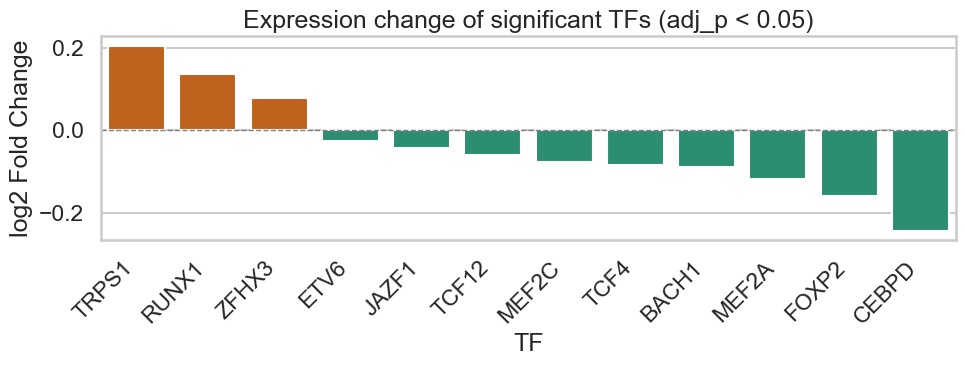

,TF,log2FC,pval,adj_pval
16,TRPS1,0.205077,3.837883e-06,1.918942e-05
12,RUNX1,0.136941,5.296132e-13,5.296132e-12
19,ZFHX3,0.078199,7.602342e-05,2.172098e-04
4,ETV6,-0.025171,2.557025e-03,5.114051e-03
9,JAZF1,-0.042056,2.884064e-02,4.806774e-02
14,TCF12,-0.060705,1.678193e-07,1.118796e-06
11,MEF2C,-0.076740,1.385021e-05,5.540085e-05
15,TCF4,-0.084957,4.973754e-05,1.657918e-04
0,BACH1,-0.088153,4.396983e-04,9.771074e-04
10,MEF2A,-0.118757,1.007451e-31,2.014903e-30


In [161]:
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

def compare_tf_expression_simple(
    rna,
    dfG_healthy,
    dfG_diseased,
    condition_col="condition",
    healthy_label="Healthy",
    diseased_label="Diseased",
    top_per_condition=15
):
    """
    Compare expression of top TF hubs (by summed importance score)
    between healthy and diseased samples.
    Uses rna.var['feature_name'] to match TF symbols.
    Keeps only TFs with adjusted p-value < 0.05.
    """

    # --- 1. Get top TFs from each network ---
    hubs_H = (dfG_healthy.groupby("tf_symbol")["importance"]
              .sum().sort_values(ascending=False).head(top_per_condition))
    hubs_D = (dfG_diseased.groupby("tf_symbol")["importance"]
              .sum().sort_values(ascending=False).head(top_per_condition))
    top_tfs = pd.Index(hubs_H.index).union(hubs_D.index)
    print(f"[info] Comparing {len(top_tfs)} top TFs across conditions...")

    # --- 2. Map TF symbols to feature IDs in rna.var ---
    if "feature_name" not in rna.var.columns:
        raise ValueError("rna.var must contain a 'feature_name' column with gene symbols.")
    symbol_to_id = {sym: gene for gene, sym in rna.var["feature_name"].items()}

    tf_in_data = [symbol_to_id[tf] for tf in top_tfs if tf in symbol_to_id]
    tf_found = [tf for tf in top_tfs if tf in symbol_to_id]
    if len(tf_in_data) == 0:
        raise ValueError("None of the TFs were found in rna.var['feature_name'].")

    # --- 3. Extract expression and metadata ---
    X = rna[:, tf_in_data].to_df()
    X.columns = tf_found  # rename to symbols
    X["condition"] = rna.obs[condition_col].values

    # --- 4. Differential expression (Wilcoxon) ---
    results = []
    for tf in tf_found:
        vals_H = X.loc[X["condition"] == healthy_label, tf]
        vals_D = X.loc[X["condition"] == diseased_label, tf]
        stat, p = ranksums(vals_D, vals_H)
        log2fc = np.log2(vals_D.mean() + 1e-6) - np.log2(vals_H.mean() + 1e-6)
        results.append((tf, log2fc, p))

    df_de = pd.DataFrame(results, columns=["TF", "log2FC", "pval"])
    df_de["adj_pval"] = multipletests(df_de["pval"], method="fdr_bh")[1]
    df_de = df_de.sort_values("log2FC", ascending=False)

    # --- 5. Filter only significant TFs ---
    df_sig = df_de.query("adj_pval < 0.05").copy()
    print(f"[info] {len(df_sig)} significant TFs (adj_pval < 0.05)")

    # --- 6. Plot significant TFs ---
    if not df_sig.empty:
        plt.figure(figsize=(10, 4))
        sns.barplot(
            data=df_sig,
            x="TF", y="log2FC",
            palette=["#d95f02" if v > 0 else "#1b9e77" for v in df_sig["log2FC"]]
        )
        plt.axhline(0, color="gray", linestyle="--", lw=1)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("log2 Fold Change")
        plt.title("Expression change of significant TFs (adj_p < 0.05)")
        plt.tight_layout()
        plt.show()
    else:
        print("[info] No TFs passed the significance threshold (adj_pval < 0.05).")

    return df_sig

df_de = compare_tf_expression_simple(
    rna,
    dfG_healthy=GRNboost,
    dfG_diseased=GRNboost,
    condition_col="Cognitive status",   # or whatever your metadata column is called
    healthy_label="No dementia",
    diseased_label="Dementia",
    top_per_condition=15
)

df_de



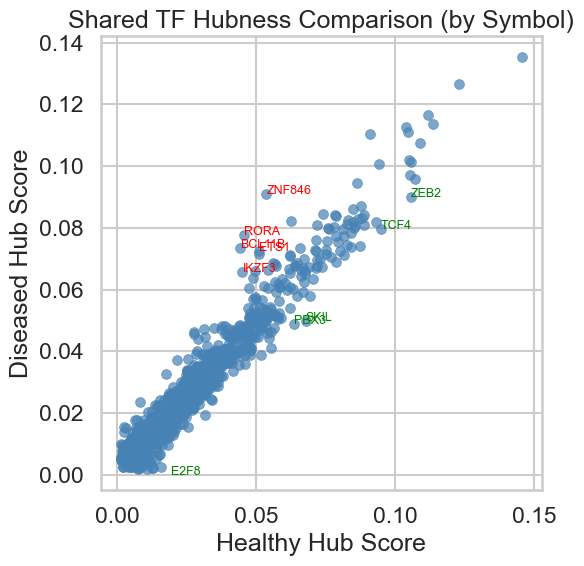

In [162]:
shared = merged[(merged['hub_score_H'] > 0) & (merged['hub_score_D'] > 0)].copy()

plt.figure(figsize=(6,6))
sns.scatterplot(
    data=shared,
    x="hub_score_H", y="hub_score_D",
    color="steelblue", s=50, alpha=0.7, edgecolor=None
)
plt.xlabel("Healthy Hub Score")
plt.ylabel("Diseased Hub Score")
plt.title("Shared TF Hubness Comparison (by Symbol)")

# Label top gains/losses
top_up = merged.head(5).index
top_down = merged.tail(5).index
for tf in top_up:
    plt.text(merged.loc[tf,'hub_score_H'], merged.loc[tf,'hub_score_D'], tf, color='red', fontsize=9)
for tf in top_down:
    plt.text(merged.loc[tf,'hub_score_H'], merged.loc[tf,'hub_score_D'], tf, color='green', fontsize=9)
plt.tight_layout()
plt.show()



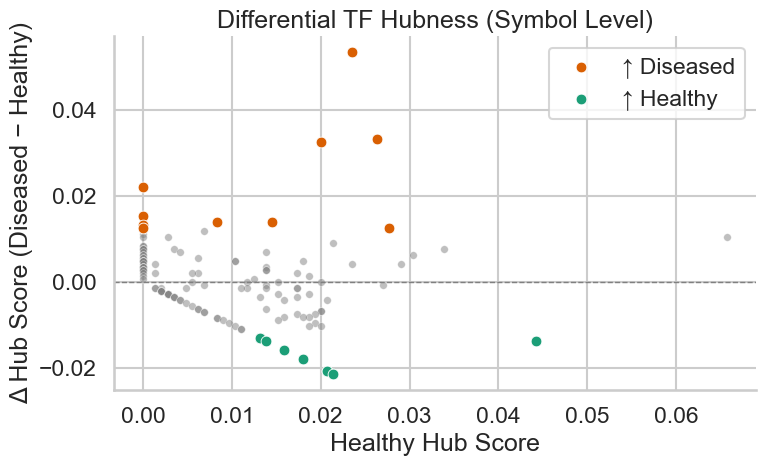

In [86]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=merged,
    x="hub_score_H", y="delta",
    color="gray", alpha=0.5, s=30
)
sns.scatterplot(
    data=merged.head(10), x="hub_score_H", y="delta",
    color="#d95f02", s=60, label="↑ Diseased"
)
sns.scatterplot(
    data=merged.tail(10), x="hub_score_H", y="delta",
    color="#1b9e77", s=60, label="↑ Healthy"
)
plt.axhline(0, ls='--', color='gray', lw=1)
plt.xlabel("Healthy Hub Score")
plt.ylabel("Δ Hub Score (Diseased − Healthy)")
plt.title("Differential TF Hubness (Symbol Level)")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()


In [163]:
import gseapy as gp

# Take top 30 hub TFs that gained in disease
top_disease_TFs = merged.sort_values('hub_score', ascending=False).head(30).index.tolist()

# Enrich using Enrichr GO Biological Process
enr = gp.enrichr(gene_list=top_disease_TFs,
                 gene_sets=['GO_Biological_Process_2021'],
                 organism='Human',
                 description='disease_hubs',
                 outdir=None)

# Show top enriched terms
enr.results.head(10)[['Term','Adjusted P-value','Combined Score']]


/opt/anaconda3/envs/scenic/lib/python3.11/site-packages/gseapy/enrichr.py:427: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.results = self.results.append(res, ignore_index=True)


,Term,Adjusted P-value,Combined Score
0,regulation of transcription by RNA polymerase ...,8.654717e-21,3798.388100
1,"regulation of transcription, DNA-templated (GO...",8.654717e-21,3692.321439
2,"positive regulation of transcription, DNA-temp...",1.381017e-10,503.337930
3,"negative regulation of transcription, DNA-temp...",2.444866e-08,340.482136
4,positive regulation of transcription by RNA po...,1.783020e-07,279.020386
5,negative regulation of transcription by RNA po...,1.688117e-06,246.530062
6,positive regulation of nucleic acid-templated ...,1.688117e-06,283.810973
7,negative regulation of nucleic acid-templated ...,1.136838e-05,233.970886
8,negative regulation of cellular macromolecule ...,3.503303e-05,180.802285
9,regulation of gene expression (GO:0010468),6.883675e-05,115.026354


In [164]:
top_healthy_TFs = merged.sort_values('hub_score', ascending=False).head(30).index.tolist()

enr2 = gp.enrichr(gene_list=top_healthy_TFs,
                  gene_sets=['GO_Biological_Process_2021'],
                  organism='Human',
                  description='healthy_hubs',
                  outdir=None)

enr2.results.head(10)[['Term','Adjusted P-value','Combined Score']]


/opt/anaconda3/envs/scenic/lib/python3.11/site-packages/gseapy/enrichr.py:427: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.results = self.results.append(res, ignore_index=True)


,Term,Adjusted P-value,Combined Score
0,regulation of transcription by RNA polymerase ...,1.130772e-20,3798.388100
1,"regulation of transcription, DNA-templated (GO...",4.853714e-19,2457.497868
2,"negative regulation of transcription, DNA-temp...",6.666601e-15,1145.627751
3,negative regulation of transcription by RNA po...,6.741238e-13,934.789251
4,positive regulation of transcription by RNA po...,3.334712e-11,604.069320
5,"positive regulation of transcription, DNA-temp...",7.129277e-11,503.337930
6,"DNA damage response, signal transduction by p5...",6.499040e-05,793.031767
7,negative regulation of cell cycle process (GO:...,9.230936e-05,659.463376
8,mitotic G1 DNA damage checkpoint signaling (GO...,9.230936e-05,645.483009
9,"DNA damage response, signal transduction by p5...",1.398761e-04,539.452696


/var/folders/6d/6qsg8p2d5xzc0tmwq4794_040000gn/T/ipykernel_11141/3025864654.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


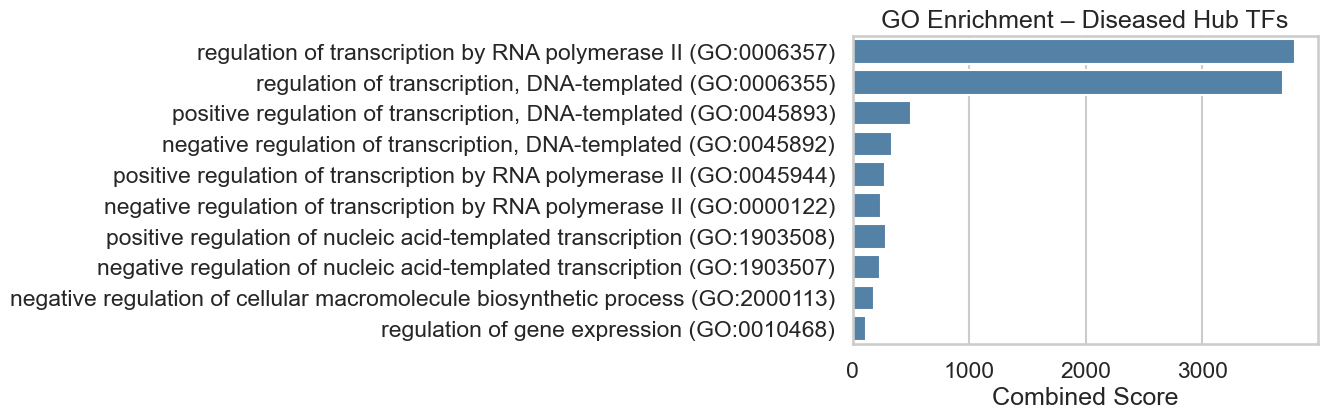

In [165]:
import seaborn as sns, matplotlib.pyplot as plt

top = enr.results.sort_values('Adjusted P-value').head(10)
plt.figure(figsize=(6,4))
sns.barplot(y='Term', x='Combined Score', data=top, color='steelblue')
plt.xlabel('Combined Score')
plt.ylabel('')
plt.title('GO Enrichment – Diseased Hub TFs')
plt.tight_layout()
plt.show()
